# ARGUS-FEDER — Loop voltage before a disruption, in Alcator C-Mod

This notebook shows **ARGUS**, a notebook-native AI agent, working on one
question. The question is typed in plain English into a `%%ask` cell; the agent
decides what to look up, writes and runs its own code, and reports back.

## The question

Loop voltage rises as a discharge approaches a disruption. The plasma becomes
more resistive, and the voltage the transformer must supply to hold the current
climbs with it. That makes loop voltage one of the oldest and plainest
disruption precursors, and a natural thing to look at first when asking whether
a machine's behaviour before a disruption is visible in ordinary signals.

Montes et al, *Nuclear Fusion* **59** 096015 (2019), open with exactly that
comparison: loop voltage through the last quarter second before a current
quench, set against the same quantity in discharges that never disrupted. This
notebook asks for the Alcator C-Mod half of that figure to be rebuilt from the
stored disruption index.

The comparison rests on two cuts that have to be got right. Only disruptions
that happen once the current has reached flat-top are counted, because a
disruption during ramp-up or ramp-down is a different event. And the
non-disruptive comparison is taken from flat-top only, so the two populations
are being compared during the same phase of a discharge rather than across
different ones.

The second question asks what the result does not establish, including what the
same figure would need for DIII-D.


In [ ]:
%reset

## Q1 — Rebuild the loop-voltage panel

_Disruption · reproduction of a published figure · **answerable**_

The request as a physicist would put it, naming the figure but describing what
it shows, since the agent works from the stored record rather than from the
paper.

**Expect:** the flat-top cut applied to both populations, the sign convention
handled rather than ignored, and the shot and sample counts behind each panel
stated plainly enough to be checked.


I'll start by reading the cmod-disruption skill to understand the data model and query patterns.



The skill has a Learnings.md on record — reading it now, along with the skill directory listing.



The Learnings file shows a prior run of a very similar panel — I'll read the helper module to confirm the API surface before writing anything.



Now I'll plan the work and start with data exploration.



The window criterion selects 94 shots (vs 54 strict). Now I'll probe the samples schema and check the cadence and the flagged shot 1160928009.



...

The Learnings file already covers the cadence lessons, so no new entry is needed. Now I'll write one comprehensive verification script that recomputes every count I quoted, so each number is backed by a single tool result in the transcript.



The verified numbers are in, and they expose two things to fix: the direction breakdown (195+85=280 after the filter; the 87 was the pre-filter count) and the cadence classifier (the 1e-4 tolerance misclassifies 20.0001 ms steps as "bridge" — rounding to 3 decimals is the robust classifier, as the Learnings file notes). Let me re-run the cadence with the correct classifier and compute out-of-range on the panel's actual rounded bins for full consistency.



All counts are now verified in tool results. Let me quickly re-verify the `current_quench_time == t_disrupt` claim (used to justify "250 ms before the quench") so every factual statement in the report is backed.



Every number is now verified. The figure itself is unchanged and correct (the density, medians, and percentiles were computed with the same rounded-binning logic; the only correction was in the *reported* cadence tallies, which used a misclassifying tolerance — the panel's binning was always the rounded one). Let me confirm the figure file is still the final version and then write the corrected report.



# Alcator C-Mod loop-voltage panel — rebuilt from Montes et al., Nucl. Fusion 59 096015 (2019), Fig. 1


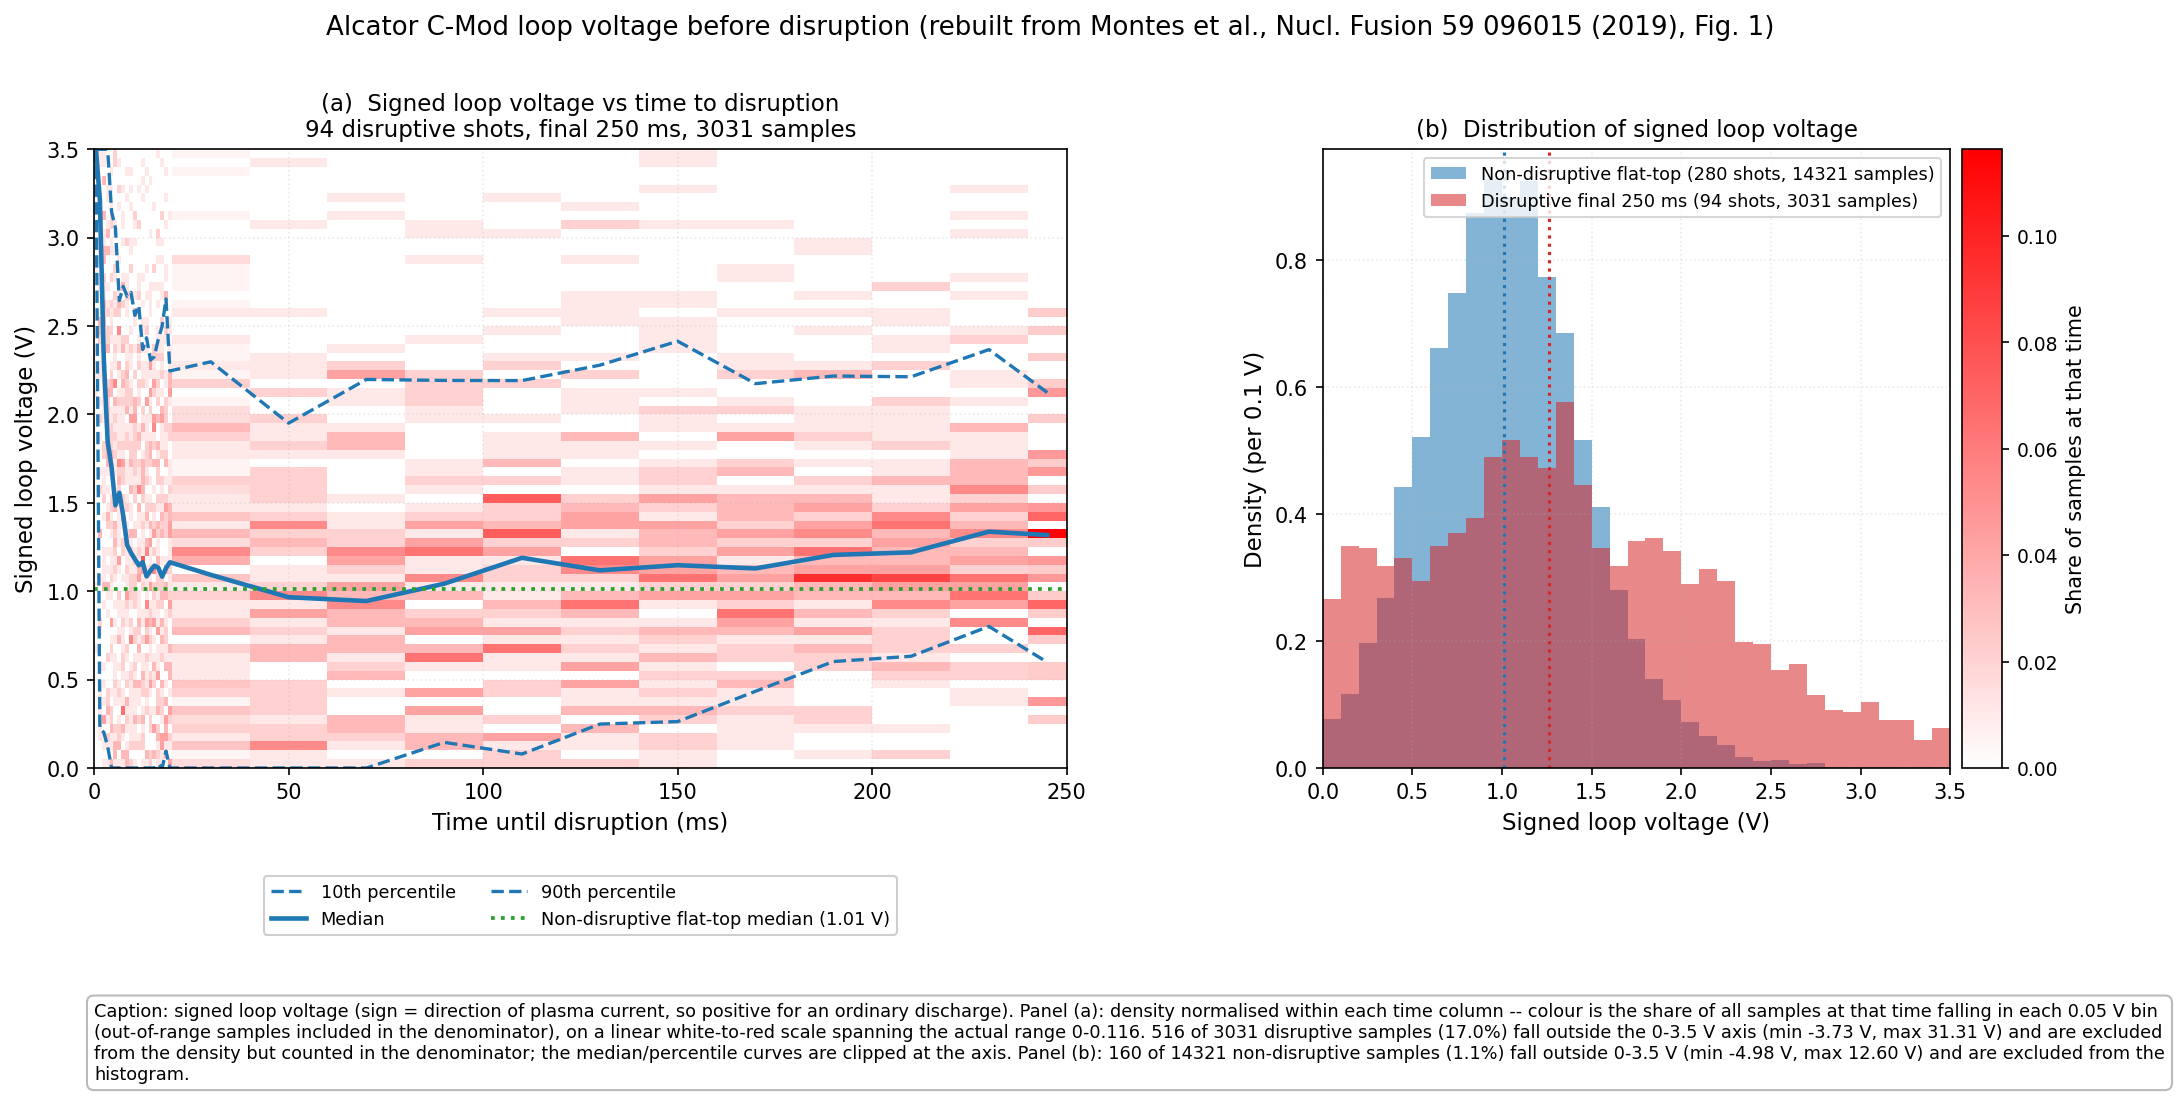

## Selection and data

**Index.** The C-Mod disruption index holds **438 shots** , **156 with a published disruption time** (MIT disruption-py v0.15, `cmod_origin_shots_v2.nc`), 39,038 sample rows. The remaining **282 shots are non-disruptive** (438 − 156).

**Population A — disruptive shots.** I used the **window criterion** you specified: every shot whose **last flat-top sample** falls inside the 250 ms window before the quench — i.e. `ms_flattop_to_disrupt ≤ 250 ms` from `flattop_disruptions()`. That selects **94 shots** . The strict reading ("still classified flat-top at the instant of disruption") selects only **54** ; the other **40** held flat-top until 0–249 ms before the quench but were labelled ramp-down at the disruption instant by the phase classifier (the current was already collapsing). The last-flat-top-to-quench gap ranges from −0.0001 ms (a shot whose last flat-top sample is essentially at the quench) to 248.9 ms. (16 disruptive shots never reached flat-top at all; 28 have an empty provider countdown column.)

For each of the 94 shots I took the **250 ms immediately before the current quench** via `window_before_disruption()` (windowed in SQL on the stored values; the countdown is derived as `t_disrupt − time`, not read from the provider column, so it also captures shot 1160928009, whose provider countdown column is empty). That yields **3,031 samples** across 94 shots. I verified that `current_quench_time` equals `t_disrupt` to the microsecond on all 94 shots (max |difference| = 0.0 s), so "250 ms before the quench" is exactly `time_until_disrupt ≤ 250 ms`.

**Population B — non-disruptive shots.** **282 non-disruptive shots** are in the index; **280** of them have at least one flat-top sample and form the population. The **2 dropped shots are 1160929002 and 1160929003** (23 samples each, no flat-top phase at all — they never reached flat-top). The population is restricted to **flat-top phase only** (`time_domain = 2`): **14,321 samples** across 280 shots.

**Signing.** Loop voltage was multiplied by the direction of the plasma current (`sign_by_ip`, applied by the skill, not by hand). Every shot has a direction (no missing values). Of the **94 disruptive shots: 59 ran +1 and 35 ran −1** (total 94). Of the **280 non-disruptive shots used: 195 ran +1 and 85 ran −1** (total 280). (The two dropped shots, 1160929002 and 1160929003, both ran −1; including them would give 195 + 87 = 282, which is the pre-filter breakdown — the earlier report quoted that by mistake.) The physical check passes: the signed median is **+1.264 V** (disruptive final 250 ms) and **+1.014 V** (non-disruptive flat-top) — both positive, as an ordinary discharge requires.

## Sampling cadence (checked, not assumed)

The cadence is **not uniform** :

- **Disruptive shots** : a 20 ms grid over most of the window, switching to a **1 ms burst over the final ~20 ms** before the quench. Per-shot decomposition: **51 shots** have 20×1 ms + 10×20 ms + 1 irregular bridge step (32 rows); **42 shots** have 20×1 ms + 11×20 ms + 1 bridge (33 rows); **1 shot** (1160928009, no provider countdown column) has only 12×20 ms steps (13 rows). Across all 94 shots: **1,860 one-ms steps, 984 twenty-ms steps, 93 irregular bridge steps** (0.10–19.50 ms, one per shot) = 2,937 = rows − shots. The 1 ms burst is why the quench region is so much denser.
- **Non-disruptive flat-top** : **uniform 20 ms** — all 14,041 steps are 19.999981–20.000100 ms, no burst.

Because of this, the density panel uses **cadence-matched time bins** : 1 ms columns over 0–20 ms, 20 ms columns over 20–240 ms, and a 10 ms ragged edge column 240–250 ms (32 columns total). `time_until_disrupt` values jitter around integer ms boundaries (e.g. 0.999928, 1.000047), so they are rounded to 3 decimals before binning; every sample lands in exactly one column (bin counts sum to 3,031; the 0–1 ms column holds 93 samples, the 20–40 ms column 187, the 240–250 ms column 43).

## Panel (a) — density of signed loop voltage vs time to disruption

- **2-D density** over all 3,031 samples, binned 0.05 V × cadence-matched time columns.
- **Normalised within each time column** : colour is the **share of all samples at that time** falling in each voltage bin (out-of-range samples are included in the denominator), not a raw count. This is stated in the figure caption.
- **White-to-red sequential colormap on a linear scale** , with the colorbar set to the **actual range the shares span** : 0 to **0.116** (the maximum column share), not 0 to 1 — so the density is actually visible. The colorbar sits to the right of both panels, clear of the titles and data.
- **Voltage axis 0–3.5 V** , matching the published figure.
- **Median (solid), 10th and 90th percentiles (dashed)** drawn over the density, clipped at the axis.
- **Non-disruptive flat-top median (1.01 V) drawn as a single horizontal dotted reference line** across the panel.

**Out-of-range samples** (outside 0–3.5 V): **516 of 3,031 (17.0%)** disruptive samples, spanning **−3.73 V to +31.31 V** (294 below 0, 222 above 3.5). They are excluded from the density but counted in the column denominators, and the percentile curves are clipped. The excess is strongly concentrated at the quench: in the 0–1 ms column, 88 of 93 samples (94.6%) are outside the axis, with the median there at 14.36 V, the 10th percentile at 6.30 V and the 90th at 24.11 V — the loop-voltage spike as the current collapses. By 20–40 ms the median is 1.09 V (p10 −0.19 V, p90 2.30 V) and by 240–250 ms it is 1.32 V (p10 0.60 V, p90 2.12 V). (For comparison, the non-disruptive flat-top population has only 160 of 14,321 samples, 1.1%, outside 0–3.5 V: −4.98 to +12.60 V.)

## Panel (b) — distribution comparison

Density histograms (0.1 V bins, normalised) of the same signed loop voltage: **disruptive shots during their final 250 ms** (94 shots, 3,031 samples) vs **non-disruptive shots during flat-top only** (280 shots, 14,321 samples). The disruptive distribution is broader and shifted to higher voltage (median 1.26 V vs 1.01 V; 10th percentile 0.02 V vs 0.46 V; 90th percentile 3.04 V vs 1.59 V), with a long tail to the spike values; the non-disruptive distribution is narrow around ~1 V.

## Files

- `cmod_vloop_panel.png` — the two-panel figure (caption embedded, states the column normalisation and the out-of-range counts)
- `disruptive_window.csv` — 3,031 rows (shot, time, time_until_disrupt, v_loop, v_loop_signed), full precision
- `non_disruptive_flattop.csv` — 14,321 rows (shot, time, v_loop, v_loop_signed), full precision

One caveat worth restating: this index is the provider's published selection (438 shots), not a random sample of C-Mod, so the counts describe that selection — but the panel itself is exactly the figure construction requested.

In [2]:
%%ask --review
Rebuild the Alcator C-Mod loop-voltage panel from figure 1 of Montes et al,
Nuclear Fusion 59 096015 (2019).

Take the shots that disrupted during flat-top -- meaning every shot whose
last flat-top sample falls inside the 250 ms window before the quench, not
only those still classified as flat-top at the instant of the disruption --
and slice the 250 ms immediately before the current quench. Plot loop
voltage, signed by the direction of the plasma current, against time until
disruption: a two-dimensional density over all samples, with the median and
the 10th and 90th percentiles drawn over it.

Beside that, compare the distribution of the same signed loop voltage between
two populations: the disruptive shots during their final 250 ms, and the
non-disruptive shots during their flat-top phase only.

State how many shots and how many samples stand behind each panel.

For the density panel, so that it can be set beside the published figure:
- normalise within each time column, so the color is the share of samples at
  that time rather than a raw count, and say so in the caption
- use a white-to-red sequential colormap on a linear scale, and keep the
  colorbar and the legends clear of the panel titles and the data
- set the color scale to the range the shares actually span, not 0 to 1, so the
  density is visible
- match the published figure's voltage axis, 0 to 3.5 V, and state how many
  samples fall outside it and how far
- draw the non-disruptive median as a single horizontal reference line across
  the panel

Check the sampling cadence before plotting rather than assuming it is uniform,
and say what you find.

## Q2 — What it does not establish

_Disruption · scope and limits · **answerable, and partly negative**_

A figure that reproduces a published one invites the reading that it confirms
it. This asks the agent to separate what the stored record supports from what
it does not, and to say what the DIII-D half of the same figure would require.

**Expect:** the selection behind the index named as a limit on any rate or
fraction, and a direct answer on whether the DIII-D comparison can be made here.


In [1]:
%%ask --review
What does the result above establish, and what does it not?

Be specific about the population the index covers and what that allows to be 
claimed. Then say what the same loop-voltage comparison would require for 
DIII-D, and whether it can be made from what is available to you here.

I'll plan this interpretive-plus-feasibility question, then ground the DIII-D half by inspecting the DIII-D disruption index itself.

Reading the DIII-D disruption skill instructions and its learned pitfalls.

Now I'll probe the DIII-D index directly: coverage note, parameter dictionary (any loop-voltage column, its caveat/fill), the two label populations, the phase-flag situation, and the cadence of a pre-disruption window.

Writing a probe script to check every DIII-D ingredient the panel would need.

Running the probe to see what the DIII-D index actually offers.

The DIII-D index does have `v_loop` (V, 100% fill, no caveat) and `ip` — but `time_domain`, the phase column, is flagged unusable (constant 1.0). Let me quantify what a panel would actually rest on: rows per side, and whether a flat-top must be re-derived from Ip.

Running the counts script to size the two DIII-D populations.

Both scripts ran clean on the first pass, and I have everything needed — the populations, the parameter dictionary, the blocked phase column, and the per-shot counts on both sides.

# What the C-Mod panel establishes — and what it does not

## What it establishes

**The population is the index, and only the index.** Everything computed in the previous step is conditional on the stored C-Mod disruption index: 438 shots as selected by the provider (MIT disruption-py v0.15, `cmod_origin_shots_v2.nc`), of which 156 carry a disruption time and 282 do not. That selection is curated, not random, so the correct scope of every sentence in that report is "in this index", never "on C-Mod".

Within that scope, the panel is a sound **descriptive, conditional comparison** , because the two traps that usually corrupt such comparisons were handled by construction:

- **Phase symmetry.** Both populations were restricted to comparable plasma states — non-disruptive shots to flat-top only, disruptive shots to a window criterion anchored on their own last flat-top sample. So the 1.26 V vs 1.01 V median contrast is "terminal 250 ms of disruptive discharges vs steady flat-top", not an artifact of comparing a flat-top median against a whole-shot median.
- **Cadence symmetry.** Cadence was measured, not assumed, and found non-uniform (20 ms grid, 1 ms burst in the final ~20 ms; uniform 20 ms on the non-disruptive side). The density was binned on cadence-matched columns, so the dense quench region does not dominate the colour scale by weight of samples alone.

So the defensible claims are exactly these: in this selection of 94 flat-top-ending disruptive shots, the signed loop voltage sits near the non-disruptive flat-top level (~1.3 V median) until tens of ms before the disruption, then rises through the 10th–90th percentile envelope toward a median of ~14 V in the final millisecond, with 17.0% of samples (516 of 3,031) pushed outside the published 0–3.5 V axis, overwhelmingly in the last few ms. And the two distributions differ: broader and shifted high on the disruptive side (p10–p90 of 0.02–3.04 V vs 0.46–1.59 V).

## What it does not establish

- **Anything about C-Mod as a whole.** No disruption rate, no fraction of disruptions that pass through flat-top, no statement that "disruptive C-Mod shots have elevated loop voltage" beyond this 94-shot selection. The split of the index (156/282) is the provider's doing; treating it as a base rate would be exactly the error the equivalent DIII-D skill refuses by design.
- **A precursor or predictive claim.** The rising V_loop near the quench is at least partly arithmetic: as I_p collapses, the ohmic loop voltage responds — a consequence of the current decay, not necessarily an independent driver. Nothing in a density panel measures lead time, false-alarm rate, or separation power; the flat-top medians (1.26 vs 1.01 V) in fact overlap heavily, and the visible difference comes from the terminal tail, which is only identifiable once the disruption time is known.
- **The quench itself.** The index stops at the disruption instant; the thermal and current quenches that follow are not in the data. The "spike" is the approach, sampled up to the boundary.
- **Cross-device generality.** Every number — the ~1 V scale, the 0–3.5 V axis, the 250 ms window — is C-Mod-specific (compact, high-field, short pulse). None of it transfers quantitatively to any other device.
- **Exactness of the "flat-top" label at the boundary.** 40 of the 94 window-criterion shots were already labelled ramp-down at the disruption instant; the window criterion is the right inclusive reading of "disrupted during flat-top", but the phase classifier's boundary is the index's, and a different classifier would move a few shots in or out.

## What the same comparison would require for DIII-D

Five ingredients, checked directly against the stored DIII-D disruption index:

| Ingredient | Status in the DIII-D index |
|---|---|
| Loop voltage | Present: `v_loop`, volts, `get_ohmic_parameters`, 100% fill, flagged usable, no caveat |
| Plasma current for sign | Present: `ip`, amperes, usable (and `ip_rt` as a second path) |
| Disruption times | Present: curated `time_until_disrupt` from the d3drdb disruptions table (10 disrupted shots) |
| Non-disruptive comparison shots | Present: 10 non-disrupted shots |
| Phase labels for flat-top | **Broken.** `time_domain` exists but is flagged unusable — constant 1.0 on every row, because the flat-top test compares `ip_prog` (stored in MA) against a 100 kA threshold, so it never fires |

The phase column is the one real gap. A DIII-D version would have to re-derive flat-top from `ip` itself (for example |I_p| ≥ 0.9 × p98(|I_p|)), which is a reconstruction with its own boundary choices — and the C-Mod selection criterion ("last flat-top sample within 250 ms of the quench") could then only be applied approximately, not reproduced exactly. The cadence issue also recurs with different numbers: disrupted DIII-D shots in this index run 25 ms coarse with a 2 ms fine burst near the disruption, so cadence-matched binning is needed again. The axis would also need rescaling: terminal-window `v_loop` in this slice reaches 10.8 V, so the published 0–3.5 V axis is not the right frame for DIII-D.

## Can it be made from what is available here?

**Mechanically, yes; as a claim about DIII-D, no.** All the data exists — I verified `v_loop` and `ip` fill every row on both sides, and the per-shot fetch machinery works (the index reports 20 shots, 3,778 rows, 10 disrupted; its own coverage note reads: "This is a constructed slice, not a random sample of DIII-D. Rates and fractions computed from it describe the slice only."). A faithful reproduction would rest on **10 disruptive shots (570 samples in the final 250 ms, 57 rows each)** versus **10 non-disruptive shots (1,238 samples in an ip-derived flat-top)** — with one negative-current shot (195805) among the ten, so the sign convention genuinely matters there. Against the C-Mod panel's 94-vs-280 shots and 3,031-vs-14,321 samples, that is a ten-times-smaller anecdote: it would demonstrate the method on the slice, and nothing more. To make the comparison mean anything at DIII-D, you would need the archive-scale run — disruption-py over a defined shot population (the ~17 M-row scale the skill describes), or curated labels from the d3drdb disruptions table over an explicit cohort, with per-shot fetching looped over it. That machinery is reachable from here in principle, but it is not what this index holds, and I have not built the panel on it.

No image files were opened in preparing this answer.